# Semantic Analysis and Visualization of Tweets from Public Figures and Polarizing Topics
- Andre Sae & Kyle Castillo
- November 6, 2025
- CS 329E - Elements of Data Visualization

## Research Question and Learning Model

**Research Question A:**
> How do tweets from Barack Obama, Cristiano Ronaldo, and Shakira differ in language and content, and can we visualize meaningful clusters by author using tweet semantics? 

Learning Model / Approach:
- Type: Unsupervised learning / clustering visualization.
- Method: Use semantic embeddings + t-SNE to reveal natural groupings in tweet content.
- Goal: Identify clusters corresponding to authors based on tweet characteristics.

**Research Question B:**
> Can we map out how polarization occurs using clustered text embedding latent space vectors change over time obtained from the times series tweet dicussion data over certain contreversal topic like politic and sports?

Learning Model / Approach: 
- Type: Unsupervised learning / clustering / hypothesis testing.
- Method: Use semantic embeddings + PCA to capture key features of any dicussion occuring over twitter on specific topic. Use k-mean clustering + Regression Analysis hypothesis testing to identify the change in distance between each cluster k-mean over time. 
- Goal: Identify if the cluster k mean value are fixed or do the euclidean distance between each cluster change. 

## Current Expectations About the Results

- Tweets from the same author will cluster together in the 2D plot because similar writing style and topics produce similar embeddings.
- Expect three main clusters roughly corresponding to the three authors.
- Overlaps may occur for very generic content (e.g., inspirational quotes), but overall semantic differences should be visible.
- The cluster k mean value of the conterversal topics tweets distance from other cluster k mean value increases over time to due polarization. We use Regression Analysis hypothesis testing to verify this statement.

## How to Evaluate the Project

**Research Question A:**

- Visual inspection: We check if tweets from the same author cluster together.

**Research Question B:**
- Visual inspection: Do a time series plot of the PCA cluster evolving over time to see how they are changing.
- K-Mean Comparison: Map out the dynamics of the k-mean value of each cluster over time and see if they are changing through Regression Analysis hypothesis testing. 


## Expected Model Performance:

- t-SNE + embeddings should clearly separate authors semantically.
- Clustering quality depends on how distinct the authors’ language is; moderate to strong separation in 2D visualization is expected.

In [ ]:
### 1. Import Libraries
import re

import matplotlib.pyplot as plt
import pandas as pd
from sentence_transformers import SentenceTransformer
from sklearn.manifold import TSNE

## What Is Your Dataset About?

There is two data set. The first dataset contains tweets from multiple public figures/accounts:

- Columns include: `author`, `content`, `date_time`, `number_of_likes`, `number_of_shares`.
- Focused on tweets from three authors: `BarackObama`, `Cristiano`, `shakira`.
- Each tweet is short text with metadata like posting date and engagement metrics.

In [ ]:
# Load and Prepare Data

# Define authors and sample size
TARGET_AUTHORS = ["BarackObama", "Cristiano", "shakira"]
SAMPLE_SIZE = 2000

# Load CSV
df_raw = pd.read_csv("tweets_raw.csv")

# Filter authors, select relevant columns, sample per author
df = df_raw[df_raw["author"].isin(TARGET_AUTHORS)]
df.loc[:, ["author", "content", "date_time", "number_of_likes", "number_of_shares"]]
df = df.groupby("author", group_keys=False).apply(
    lambda x: x.sample(n=SAMPLE_SIZE, replace=True)
)
df.reset_index(drop=True, inplace=True)


C:\Users\kylec\AppData\Local\Temp\ipykernel_41496\4157374256.py:13: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby("author", group_keys=False).apply(


The second dataset will have the `query`, `tweet`, `date_time`, `author`, `number_of_likes`, `number_of_shares`. The `query` is a contreversal topics such as `government shutdown` and conterversal sport figures like `Arch Manning`. The dataset not ready since the scraping logic still needs more testing to be robust enough to scrape all of the required entries for custom queries. We also need to implement a method to remove bot comments for denoising.

**Data Cleaning and Reduction**

- Filtering: Kept only tweets from the three selected authors.
- Sampling: Randomly sampled 50 tweets per author to maintain balance and reduce size.
- Cleaning: Removed URLs, mentions, hashtags, punctuation, and normalized whitespace.
- Dimensionality reduction: Text converted to embeddings and reduced to 2D using t-SNE for visualization for the first research question. We use PCA for the second research question dimension reduction method.

In [ ]:
# Text Cleaning

# Removes URLs, mentions, hashtags, punctuation, and whitespace
def clean_tweet(text):
    """Cleans raw tweet text by removing URLs, mentions, hashtags, and punctuation."""
    if pd.isna(text):
        return ""
    text = text.lower()
    text = re.sub(r"https?://\S+", "", text)
    text = re.sub(r"@\w+", "", text)
    text = re.sub(r"#\S+", "", text)
    text = re.sub(r"[^a-z0-9\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


# Apply cleaning function
df["content_cleaned"] = df["content"].apply(clean_tweet)

# Convert date_time column to datetime format
df["date_time"] = pd.to_datetime(df["date_time"], format="%d/%m/%Y %H:%M")

# Drop any rows where date parsing failed
df = df.dropna(subset=["date_time"]).reset_index(drop=True)

## Describe the Model You Are Using:

**Research Question A**

We are using SentenceTransformer embeddings followed by t-SNE for dimensionality reduction.

- SentenceTransformer converts each tweet into a dense vector that captures semantic meaning. Tweets with similar content will have similar vectors.

- t-SNE (t-distributed Stochastic Neighbor Embedding) projects high-dimensional vectors into 2D space while preserving local neighborhoods, allowing us to visualize clusters.

This combination allows us to visually explore patterns in tweet content across different authors.

In [ ]:
# Embed tweet content using SentenceTransformer
model = SentenceTransformer("all-MiniLM-L6-v2")
embeddings = model.encode(df["content_cleaned"].tolist(), show_progress_bar=True)

# Reduce embeddings to 2D using t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
features_2d = tsne.fit_transform(embeddings)

# Add 2D features back to DataFrame
df["tsne_1"] = features_2d[:, 0]
df["tsne_2"] = features_2d[:, 1]

Batches:   0%|          | 0/188 [00:00<?, ?it/s]

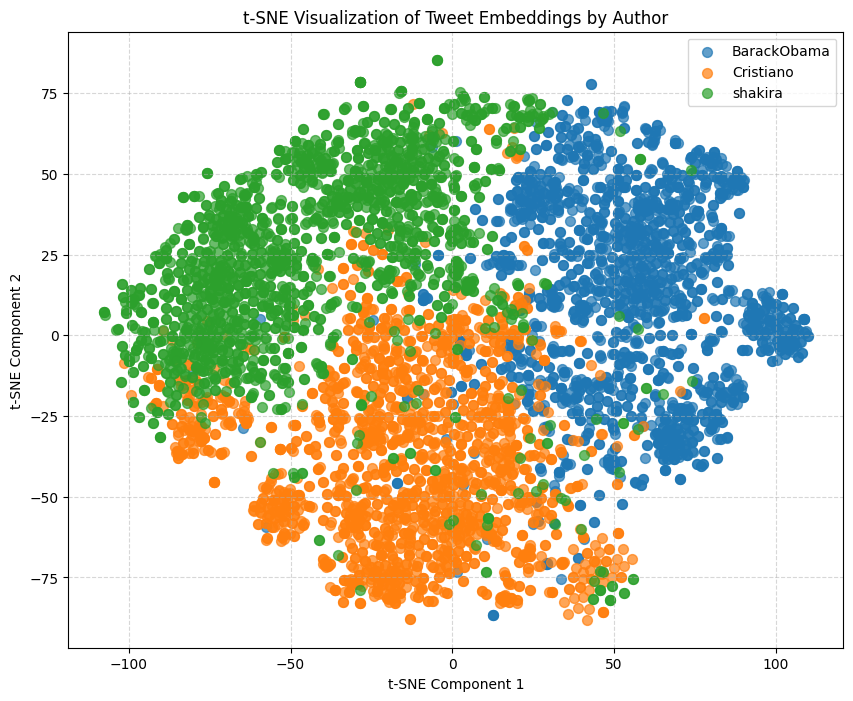

In [ ]:
### 5. Visualize Results

plt.figure(figsize=(10, 8))

for author in df["author"].unique():
    subset = df[df["author"] == author]
    plt.scatter(
        subset["tsne_1"],
        subset["tsne_2"],
        label=author,
        alpha=0.7,
        s=50,  # marker size
    )

plt.title("t-SNE Visualization of Tweet Embeddings by Author")
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

**Interpretations**

- The t-SNE visualization shows that tweets from the same author tend to cluster together, indicating that each author has a distinct style and semantic pattern in their tweets.
- Barack Obama and Cristiano Ronaldo's cluster around Shakira's tweets but eventually meet in the middle. Shakira seems to be the bridge linking Obama and Ronaldo's tweets together.
- Some overlap may occur for generic or widely used phrases, but overall semantic differences are visible.

**Ideas to Improve Results**

- Increase sample size: Using more tweets per author will give t-SNE more data to form meaningful clusters.
- Include additional features: Incorporate metadata such as likes, shares, or hashtags to enrich clustering.

**Research Question B**

In [ ]:
# Implement a denoising scheme to remove outliers:

# 1. No Denoising - Raw dog it.

# 2. Use HDBSCAN to remove noise from the data set
# Before discarding the HDBSCAN noise points, analyze them. 
# Take a random sample of 100 noise tweets and read them. Are they mostly spam? Off-topic? Or are they interesting, nuanced points? 

# 3. Use meta data metrics like like and views to remove noise from the data set
#  Remove tweets from accounts that are very new (e.g., created < 30 days ago) or have very low follower counts (e.g., < 10 followers).
# Maybe just remove tweets with zero likes and zero replies after 24 hours.

# 4. Combine both techniques for denoising.

# List out potential strengths and weakness of each denosing technique

In [ ]:
# Generate text embedding of each of the tweet using SentenceTransformer
# all-mpnet-base-v2, all-MiniLM-L6-v 
# and mixedbread-ai/mxbai-embed-large-v1

In [ ]:
# Perform PCA to extract out 3 most imporant dimension

In [ ]:
# Iterate through the entire dataset and create a plot of the
# for the first 100 entires PCA values. Calculate the k-mean value and hdbscan core value and store.
# Then, iterate to 1-101 entires. Calculate the k mean value and store.
# We keep doing this until you iterate through all of the entries. 
# Combine all of the frame to generate a video for visualization.

In [ ]:
# Finally, we perform an Regression Analysis hypothesis test against the k-mean values to see 
# if there is any change over time that isn't just noise.

**References**

- scikit-learn TSNE Documentation: [https://scikit-learn.org/stable/modules/generated/sklearn.manifold.TSNE.html](https://scikit-learn.org/stable/modules/generated/sklearn.manifold.TSNE.html)  
- GeeksforGeeks. *t-SNE Algorithm in Machine Learning*. [https://www.geeksforgeeks.org/t-sne-algorithm-in-machine-learning/](https://www.geeksforgeeks.org/t-sne-algorithm-in-machine-learning/)  
- We lightly used Generative AI to reword ideas for better clarity and flow for our reader.